## Overview (26/01/2026)

Having decided the checkerboard method with the OSQP fitting algorithm was the way to go, I've seperated out the key code to a new file called DRT.py in the aux_functions folder. This notebook is for the purpose of testing that code, to make sure it works.

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.optimize as so
import scipy.signal as ss
import matplotlib.patches as patches
import matplotlib.lines as mlines
import torch 
try:
    import pySIMsalabim as sim
except ImportError: # add parent directory to sys.path if pySIMsalabim is not installed
    sys.path.append('../../../..')
    import pySIMsalabim as sim
from pySIMsalabim.experiments import impls
from pySIMsalabim.aux_funcs import DRT as drt

In [2]:
# Define a function to give a gaussian distribution of lifetimes about a central lifetime tau on a logarithmic scale
def log_gaussian(tau, mu, sig):
    return 1/(sig*np.sqrt(2*np.pi))*np.exp(-(np.log10(tau/mu))**2/(2*sig**2))

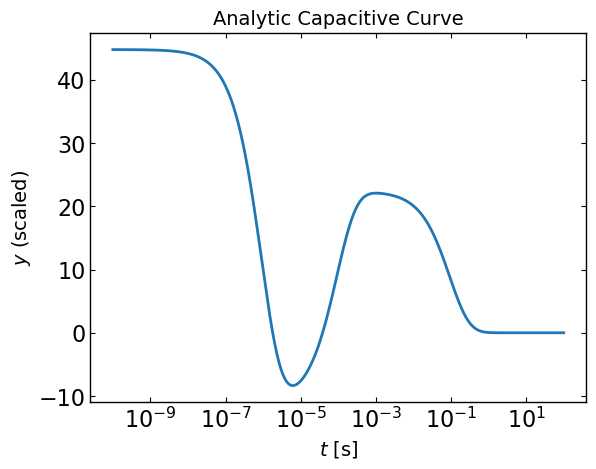

In [ ]:
# Generate an array of time values of length N
t_min = 1e-10
t_max = 1e2
time = np.geomspace(t_min, t_max, 1000)
time_ppd = int(np.log10(t_max/t_min))

# Generate array of tau values of length M such that tau_ppd ~ time_ppd (ppd - points per decade)
tau_min = t_min/np.pi   # Selected based on Nyquist spacing
tau_max = t_max/(2*np.pi)   # Selected based on Nyquist spacing
tau_dec = int(np.log10(tau_max/tau_min))
tau_values = np.geomspace(t_min/np.pi, t_max/(2*np.pi), tau_dec*time_ppd)

# Generate the analytic curve
gaussian_coeffs = [5, -3, 2]
gaussian_peaks = [1e-6, 1e-4, 1e-1] # These now correspond to when decay events begin
analytic_U = np.sum([gaussian_coeffs[i]*log_gaussian(tau_values, gaussian_peaks[i], 0.2) for i in range(len(gaussian_coeffs))], axis=0)
analytic_y = drt.predict_y(time, analytic_U, tau_values) + 20
analytic_y_scaled = (analytic_y - analytic_y.min())/(analytic_y.max() - analytic_y.min())

# Plot the data 
plt.plot(time, analytic_y)
plt.xscale('log')
plt.xlabel('$t$ [$\\text{s}$]')
plt.ylabel('$y$ (scaled)')
plt.title("Analytic Capacitive Curve")
plt.show()

In [11]:
# Calculate scaling constants
y_inf = analytic_y[-1]
y_translated = analytic_y - y_inf
y_translated_max = np.max(y_translated)
y_translated_min = np.min(y_translated)
R = y_translated_max - y_translated_min

In [16]:
# Try osqp linear fit
osqp_linear_fit = drt.osqp_linear_fit(time, analytic_y_scaled, tau_values)

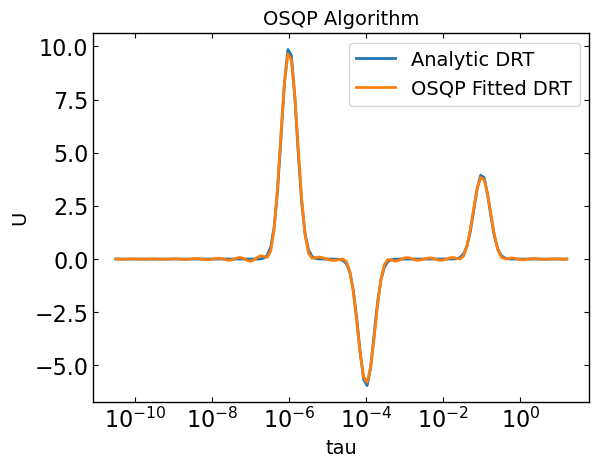

In [17]:
# Plot fitted curves 
plt.plot(tau_values, analytic_U, label='Analytic DRT')
# plt.plot(tau_values, (analytic_y.max()-analytic_y.min())*osqp_linear_fit.U, label='OSQP Fitted DRT')
plt.plot(tau_values, R*osqp_linear_fit.U, label='OSQP Fitted DRT')
plt.xlabel("tau")
plt.ylabel('U')
plt.xscale('log')
plt.title("OSQP Algorithm")
plt.legend()
plt.show()

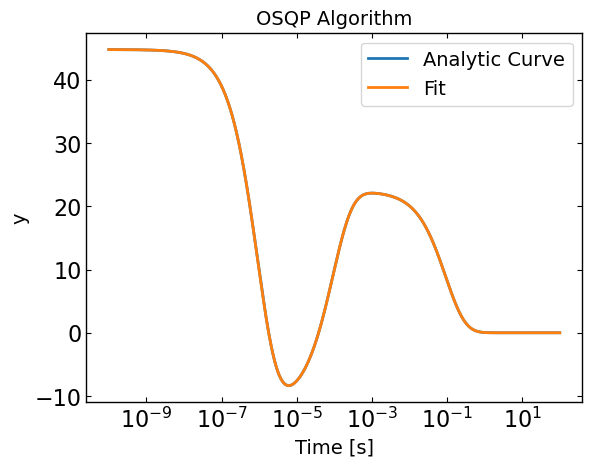

In [19]:
# Plot the two curves against each other
plt.plot(time, analytic_y, label='Analytic Curve')
# plt.plot(time, drt.predict_y(time, (analytic_y.max()-analytic_y.min())*osqp_linear_fit.U, tau_values, analytic_y[-1]), label='Fit')
plt.plot(time, drt.predict_y(time, R*osqp_linear_fit.U, tau_values, y_inf), label='Fit')
plt.xlabel('Time [s]')
plt.ylabel('y')
plt.title('OSQP Algorithm')
plt.xscale('log')
plt.legend()
plt.show()

In [8]:
fits = drt.osqp_checkerboard_fit(time, analytic_y_scaled, tau_values)

TypeError: osqp_linear_fit() got an unexpected keyword argument 'scaling'

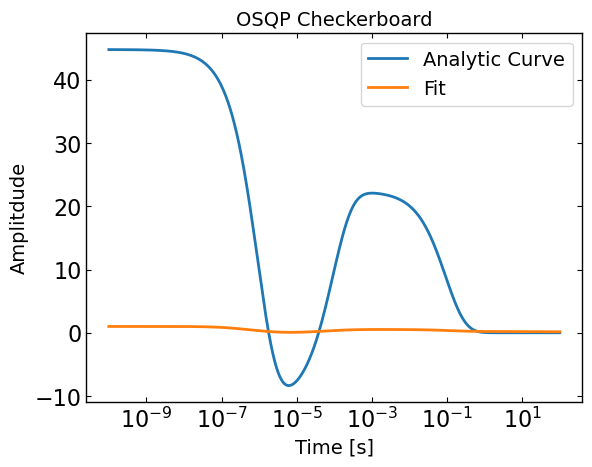

In [ ]:
plt.plot(time, analytic_y, label='Analytic Curve')
plt.plot(time, fits[-1].y, label='Fit')
plt.xscale("log")
plt.xlabel("Time [s]")
plt.ylabel("Amplitdude")
plt.title("OSQP Checkerboard")
plt.legend()
plt.show()

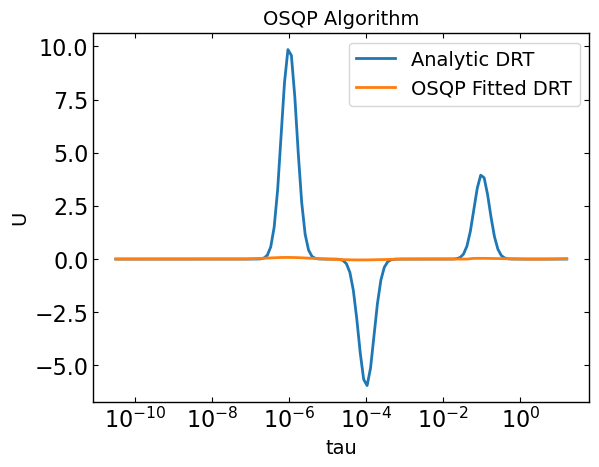

In [ ]:
# Plot fitted curves 
plt.plot(tau_values, analytic_U, label='Analytic DRT')
plt.plot(tau_values, fits[-1].U, label='OSQP Fitted DRT')
plt.xlabel("tau")
plt.ylabel('U')
plt.xscale('log')
plt.title("OSQP Algorithm")
plt.legend()
plt.show()